<a href="https://colab.research.google.com/github/ALorda/colorectal-cancer-biomarkers/blob/main/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.patches import Patch
from scipy import stats
from statsmodels.stats.multitest import multipletests

In [6]:
url = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE335nnn/GSE335441/suppl/GSE335441_gene_count_matrix.csv.gz"

expr = pd.read_csv(url, index_col=0, compression="gzip")

print("Shape:", expr.shape)
print("\nFirst few gene names:")
print(expr.index[:10].tolist())
print("\nFirst few sample names:")
print(expr.columns[:5].tolist())
expr.head()

Shape: (78691, 18)

First few gene names:
['ENSG00000223972.6|DDX11L1', 'ENSG00000310526.1|WASH7P', 'ENSG00000237613.3|FAM138A', 'ENSG00000308361.1|ENSG00000308361', 'ENSG00000290826.2|ENSG00000290826', 'ENSG00000268020.3|OR4G4P', 'ENSG00000240361.3|OR4G11P', 'ENSG00000186092.7|OR4F5', 'ENSG00000308314.1|ENSG00000308314', 'ENSG00000308579.1|ENSG00000308579']

First few sample names:
['S1', 'S2', 'S3', 'S4', 'S5']


,S1,S2,S3,S4,S5,S6,S7,S8,S9,T10,T11,T12,T13,T14,T15,T16,T17,T18
gene_id,,,,,,,,,,,,,,,,,,
ENSG00000223972.6|DDX11L1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
ENSG00000310526.1|WASH7P,1641,1752,1201,1863,2027,1752,2012,1883,1800,1677,1363,1314,2429,2031,1836,1390,1278,1523
ENSG00000237613.3|FAM138A,0,2,2,1,3,1,2,1,2,1,0,2,2,5,0,2,3,3
ENSG00000308361.1|ENSG00000308361,0,0,0,0,2,0,1,0,0,0,0,0,0,0,0,0,0,2
ENSG00000290826.2|ENSG00000290826,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [7]:



expr.index = [g.split("|")[1] if "|" in g else g for g in expr.index]

expr = expr.groupby(expr.index).sum()

expr = expr[expr.sum(axis=1) > 0]


conditions = (
    ["SW620_control"] * 3 +
    ["SW620_shHCFC2_287"] * 3 +
    ["SW620_shHCFC2_449"] * 3 +
    ["T84_control"] * 3 +
    ["T84_shHCFC2_287"] * 3 +
    ["T84_shHCFC2_449"] * 3
)

cell_line = ["SW620"] * 9 + ["T84"] * 9
condition = ["control"] * 3 + ["shHCFC2_287"] * 3 + ["shHCFC2_449"] * 3
condition = condition * 2

metadata = pd.DataFrame({
    "sample": expr.columns,
    "cell_line": cell_line,
    "condition": condition,
    "group": conditions
}).set_index("sample")

cpm = expr.divide(expr.sum(axis=0), axis=1) * 1e6
log_cpm = np.log2(cpm + 1)

print("Genes after filtering:", expr.shape[0])
print("\nMetadata:")
print(metadata)



Genes after filtering: 47196

Metadata:
       cell_line    condition              group
sample                                          
S1         SW620      control      SW620_control
S2         SW620      control      SW620_control
S3         SW620      control      SW620_control
S4         SW620  shHCFC2_287  SW620_shHCFC2_287
S5         SW620  shHCFC2_287  SW620_shHCFC2_287
S6         SW620  shHCFC2_287  SW620_shHCFC2_287
S7         SW620  shHCFC2_449  SW620_shHCFC2_449
S8         SW620  shHCFC2_449  SW620_shHCFC2_449
S9         SW620  shHCFC2_449  SW620_shHCFC2_449
T10          T84      control        T84_control
T11          T84      control        T84_control
T12          T84      control        T84_control
T13          T84  shHCFC2_287    T84_shHCFC2_287
T14          T84  shHCFC2_287    T84_shHCFC2_287
T15          T84  shHCFC2_287    T84_shHCFC2_287
T16          T84  shHCFC2_449    T84_shHCFC2_449
T17          T84  shHCFC2_449    T84_shHCFC2_449
T18          T84  shHCFC2_449

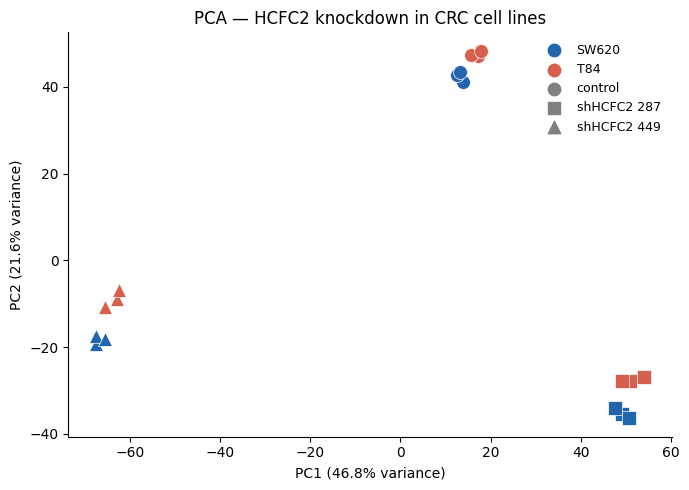

Saved as pca_plot.png


In [8]:


top_var_genes = log_cpm.var(axis=1).nlargest(5000).index
pca_input = log_cpm.loc[top_var_genes].T
scaler = StandardScaler()
pca_input_scaled = scaler.fit_transform(pca_input)

pca = PCA(n_components=2)
pcs = pca.fit_transform(pca_input_scaled)

pca_df = pd.DataFrame(pcs, columns=["PC1", "PC2"], index=metadata.index)
pca_df = pca_df.join(metadata)

fig, ax = plt.subplots(figsize=(7, 5))

colors    = {"SW620": "#2166ac", "T84": "#d6604d"}
markers   = {"control": "o", "shHCFC2_287": "s", "shHCFC2_449": "^"}
marker_labels = {"o": "control", "s": "shHCFC2 #287", "^": "shHCFC2 #449"}

for _, row in pca_df.iterrows():
    ax.scatter(
        row["PC1"], row["PC2"],
        color=colors[row["cell_line"]],
        marker=markers[row["condition"]],
        s=100, edgecolors="white", linewidths=0.5, zorder=3
    )

for cl, col in colors.items():
    ax.scatter([], [], color=col, s=80, label=cl)

for cond, mk in markers.items():
    ax.scatter([], [], color="gray", marker=mk, s=80,
               label=cond.replace("_", " "))

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title("PCA — HCFC2 knockdown in CRC cell lines")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("pca_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved as pca_plot.png")



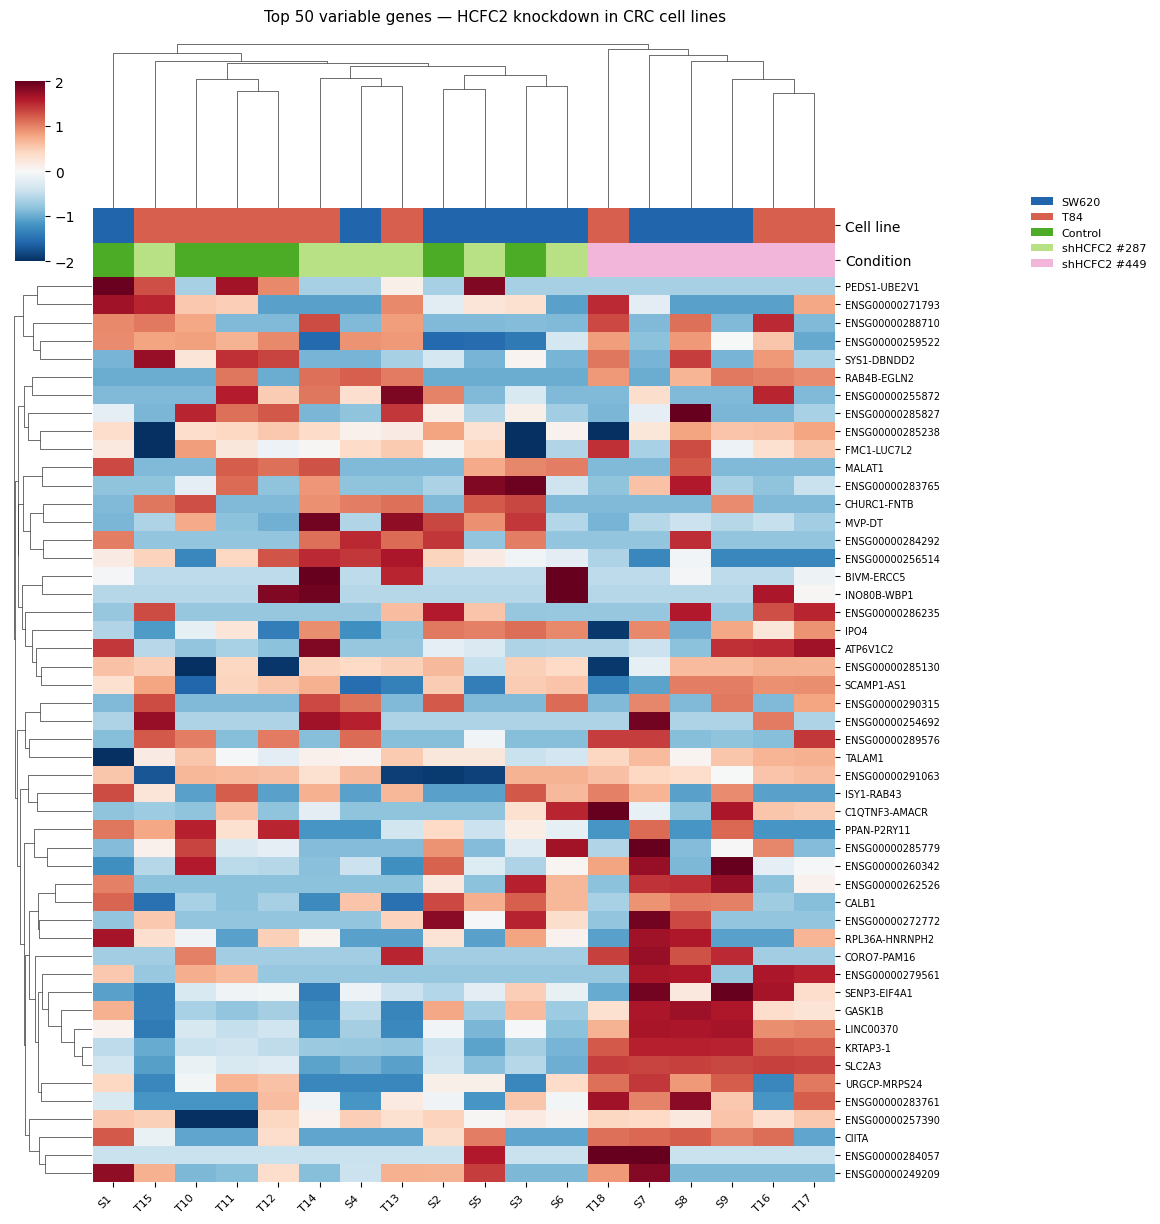

Saved as heatmap.png


In [9]:


top50 = log_cpm.var(axis=1).nlargest(50).index
heatmap_data = log_cpm.loc[top50]

heatmap_scaled = pd.DataFrame(
    StandardScaler().fit_transform(heatmap_data.T).T,
    index=heatmap_data.index,
    columns=heatmap_data.columns
)

cell_line_colors = metadata["cell_line"].map({"SW620": "#2166ac", "T84": "#d6604d"})
condition_colors = metadata["condition"].map({
    "control":     "#4dac26",
    "shHCFC2_287": "#b8e186",
    "shHCFC2_449": "#f1b6da"
})
col_colors = pd.DataFrame({
    "Cell line": cell_line_colors,
    "Condition": condition_colors
})

g = sns.clustermap(
    heatmap_scaled,
    col_colors=col_colors,
    cmap="RdBu_r",
    center=0,
    vmin=-2, vmax=2,
    figsize=(10, 12),
    dendrogram_ratio=(0.1, 0.15),
    cbar_pos=(0.02, 0.8, 0.03, 0.15),
    xticklabels=True,
    yticklabels=True
)

g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xticklabels(), fontsize=8, rotation=45, ha="right"
)
g.ax_heatmap.set_yticklabels(
    g.ax_heatmap.get_yticklabels(), fontsize=7, rotation=0
)
g.figure.suptitle("Top 50 variable genes — HCFC2 knockdown in CRC cell lines",
                   y=1.01, fontsize=11)

legend_elements = [
    Patch(facecolor="#2166ac", label="SW620"),
    Patch(facecolor="#d6604d", label="T84"),
    Patch(facecolor="#4dac26", label="Control"),
    Patch(facecolor="#b8e186", label="shHCFC2 #287"),
    Patch(facecolor="#f1b6da", label="shHCFC2 #449"),
]
g.ax_heatmap.legend(
    handles=legend_elements, loc="upper left",
    bbox_to_anchor=(1.25, 1.1), frameon=False, fontsize=8
)

plt.savefig("heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved as heatmap.png")



status
ns      15143
down      116
up         69
Name: count, dtype: int64


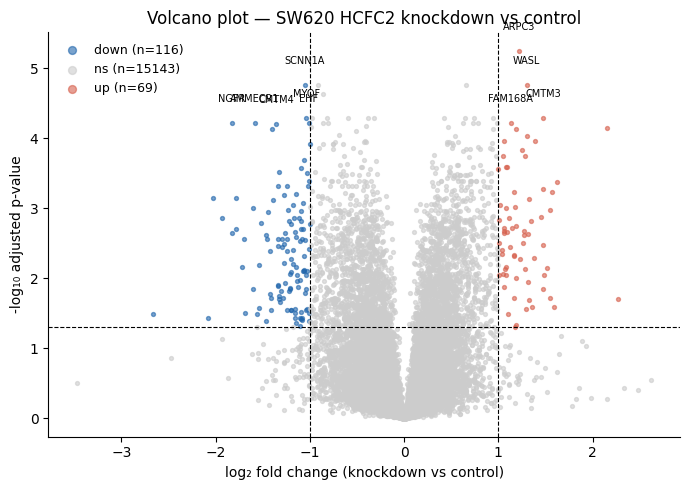

Saved as volcano_SW620.png


In [10]:



sw620_ctrl  = [s for s in metadata.index if metadata.loc[s,"group"] == "SW620_control"]
sw620_kd    = [s for s in metadata.index if metadata.loc[s,"cell_line"] == "SW620"
               and metadata.loc[s,"condition"] != "control"]

keep = log_cpm.mean(axis=1) > 1
data = log_cpm[keep]

results = []
for gene in data.index:
    ctrl_vals = data.loc[gene, sw620_ctrl].values.astype(float)
    kd_vals   = data.loc[gene, sw620_kd].values.astype(float)
    log2fc    = kd_vals.mean() - ctrl_vals.mean()
    _, pval   = stats.ttest_ind(kd_vals, ctrl_vals)
    results.append({"gene": gene, "log2FC": log2fc, "pval": pval})

res = pd.DataFrame(results).set_index("gene").dropna()

res["padj"] = multipletests(res["pval"], method="fdr_bh")[1]
res["-log10p"] = -np.log10(res["padj"].clip(lower=1e-300))

def classify(row):
    if row["padj"] < 0.05 and row["log2FC"] >  1: return "up"
    if row["padj"] < 0.05 and row["log2FC"] < -1: return "down"
    return "ns"

res["status"] = res.apply(classify, axis=1)
counts = res["status"].value_counts()
print(counts)

fig, ax = plt.subplots(figsize=(7, 5))

color_map = {"up": "#d6604d", "down": "#2166ac", "ns": "#cccccc"}
for status, grp in res.groupby("status"):
    ax.scatter(grp["log2FC"], grp["-log10p"],
               c=color_map[status], s=8, alpha=0.6,
               label=f'{status} (n={len(grp)})', rasterized=True)

ax.axhline(-np.log10(0.05), color="black", lw=0.8, ls="--")
ax.axvline( 1, color="black", lw=0.8, ls="--")
ax.axvline(-1, color="black", lw=0.8, ls="--")

top_genes = res[res["status"] != "ns"].nlargest(10, "-log10p")
for gene, row in top_genes.iterrows():
    ax.text(row["log2FC"], row["-log10p"] + 0.3, gene,
            fontsize=7, ha="center")

ax.set_xlabel("log₂ fold change (knockdown vs control)")
ax.set_ylabel("-log₁₀ adjusted p-value")
ax.set_title("Volcano plot — SW620 HCFC2 knockdown vs control")
ax.legend(frameon=False, fontsize=9, markerscale=2)
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("volcano_SW620.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved as volcano_SW620.png")



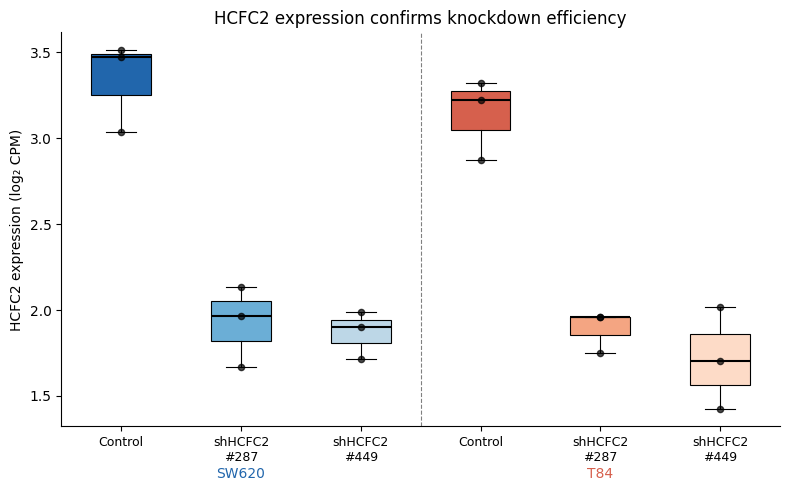

Saved as hcfc2_knockdown_confirmation.png


In [ ]:



gene = "HCFC2"
gene_data = log_cpm.loc[gene]

plot_df = pd.DataFrame({
    "log2CPM": gene_data,
    "group": metadata["group"],
    "cell_line": metadata["cell_line"],
    "condition": metadata["condition"]
})

order = [
    "SW620_control", "SW620_shHCFC2_287", "SW620_shHCFC2_449",
    "T84_control",   "T84_shHCFC2_287",   "T84_shHCFC2_449"
]
labels = ["Control", "shHCFC2\n#287", "shHCFC2\n#449",
          "Control", "shHCFC2\n#287", "shHCFC2\n#449"]

colors = ["#2166ac", "#6baed6", "#bdd7e7",
          "#d6604d", "#f4a582", "#fddbc7"]

fig, ax = plt.subplots(figsize=(8, 5))

for i, (grp, col) in enumerate(zip(order, colors)):
    vals = plot_df[plot_df["group"] == grp]["log2CPM"].values
    bp = ax.boxplot(vals, positions=[i], widths=0.5,
                    patch_artist=True,
                    boxprops=dict(facecolor=col, linewidth=0.8),
                    medianprops=dict(color="black", linewidth=1.5),
                    whiskerprops=dict(linewidth=0.8),
                    capprops=dict(linewidth=0.8),
                    flierprops=dict(marker="o", markersize=4,
                                   markerfacecolor=col, linewidth=0.5))

    ax.scatter([i] * len(vals), vals, color="black",
               s=20, zorder=3, alpha=0.7)

ax.axvline(2.5, color="gray", lw=0.8, ls="--")
ax.text(1,   ax.get_ylim()[0] - 0.3, "SW620", ha="center",
        fontsize=10, color="#2166ac")
ax.text(4,   ax.get_ylim()[0] - 0.3, "T84",   ha="center",
        fontsize=10, color="#d6604d")

ax.set_xticks(range(6))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("HCFC2 expression (log₂ CPM)")
ax.set_title("HCFC2 expression confirms knockdown efficiency")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("hcfc2_knockdown_confirmation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved as hcfc2_knockdown_confirmation.png")



status
ns      15201
down       97
up         30
Name: count, dtype: int64


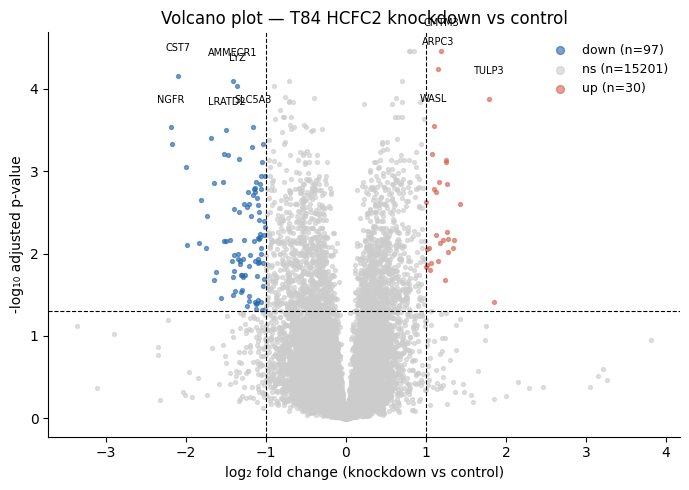

Saved as volcano_T84.png


In [ ]:



t84_ctrl = [s for s in metadata.index if metadata.loc[s,"group"] == "T84_control"]
t84_kd   = [s for s in metadata.index if metadata.loc[s,"cell_line"] == "T84"
             and metadata.loc[s,"condition"] != "control"]

results_t84 = []
for gene in data.index:
    ctrl_vals = data.loc[gene, t84_ctrl].values.astype(float)
    kd_vals   = data.loc[gene, t84_kd].values.astype(float)
    log2fc    = kd_vals.mean() - ctrl_vals.mean()
    _, pval   = stats.ttest_ind(kd_vals, ctrl_vals)
    results_t84.append({"gene": gene, "log2FC": log2fc, "pval": pval})

res_t84 = pd.DataFrame(results_t84).set_index("gene").dropna()
res_t84["padj"] = multipletests(res_t84["pval"], method="fdr_bh")[1]
res_t84["-log10p"] = -np.log10(res_t84["padj"].clip(lower=1e-300))

res_t84["status"] = res_t84.apply(classify, axis=1)
print(res_t84["status"].value_counts())

fig, ax = plt.subplots(figsize=(7, 5))

for status, grp in res_t84.groupby("status"):
    ax.scatter(grp["log2FC"], grp["-log10p"],
               c=color_map[status], s=8, alpha=0.6,
               label=f'{status} (n={len(grp)})', rasterized=True)

ax.axhline(-np.log10(0.05), color="black", lw=0.8, ls="--")
ax.axvline( 1, color="black", lw=0.8, ls="--")
ax.axvline(-1, color="black", lw=0.8, ls="--")

top_genes_t84 = res_t84[res_t84["status"] != "ns"].nlargest(10, "-log10p")
for gene, row in top_genes_t84.iterrows():
    ax.text(row["log2FC"], row["-log10p"] + 0.3, gene,
            fontsize=7, ha="center")

ax.set_xlabel("log₂ fold change (knockdown vs control)")
ax.set_ylabel("-log₁₀ adjusted p-value")
ax.set_title("Volcano plot — T84 HCFC2 knockdown vs control")
ax.legend(frameon=False, fontsize=9, markerscale=2)
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("volcano_T84.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved as volcano_T84.png")



In [ ]:



sw620_up   = set(res[res["status"]   == "up"].index)
sw620_down = set(res[res["status"]   == "down"].index)
t84_up     = set(res_t84[res_t84["status"] == "up"].index)
t84_down   = set(res_t84[res_t84["status"] == "down"].index)

shared_up   = sw620_up   & t84_up
shared_down = sw620_down & t84_down

print(f"Consistently UPREGULATED in both cell lines:   {len(shared_up)}")
print(f"Consistently DOWNREGULATED in both cell lines: {len(shared_down)}")
print(f"\nShared upregulated genes:\n{sorted(shared_up)}")
print(f"\nShared downregulated genes:\n{sorted(shared_down)}")

shared_df = pd.DataFrame({
    "gene": sorted(shared_up | shared_down),
    "direction": ["up" if g in shared_up else "down"
                  for g in sorted(shared_up | shared_down)]
})
shared_df.to_csv("shared_DEGs.csv", index=False)
print("\nSaved as shared_DEGs.csv")



Consistently UPREGULATED in both cell lines:   24
Consistently DOWNREGULATED in both cell lines: 75

Shared upregulated genes:
['AREG', 'ARPC3', 'ATOH8', 'CCNYL1', 'CDK6', 'CDKN1B', 'CMTM3', 'COX7C', 'EREG', 'FILIP1L', 'LINC02418', 'LNX1', 'MGAT4B', 'PPCS', 'RAB12', 'RABL6', 'RRAGD', 'SKA2', 'SNX16', 'STX16-NPEPL1', 'TIMP2', 'TTLL7', 'TULP3', 'WASL']

Shared downregulated genes:
['AMMECR1', 'AOC1', 'ASNS', 'ASS1', 'ATP6V0A4', 'C1orf210', 'CALML3-AS1', 'CDH1', 'CMTM4', 'CNIH3', 'CST7', 'DPEP1', 'EDAR', 'EHF', 'ELL2', 'ENSG00000227619', 'ENSG00000249574', 'ENSG00000260328', 'ENSG00000278291', 'ENSG00000293970', 'ENSG00000302910', 'ENSG00000303085', 'EPHA1', 'FAM169A', 'FGF13', 'FGFBP1', 'FXYD3', 'GPR119', 'HCFC2', 'HKDC1', 'HMGCS1', 'IL21R', 'ITGB7', 'KIF21B', 'KRT81', 'LAPTM5', 'LASTR', 'LGALS7B', 'LGR6', 'LINC00239', 'LINC02970', 'LINC03040', 'LRATD2', 'LYZ', 'MBNL2', 'MRFAP1', 'MYOF', 'NADK2', 'NET1', 'NGFR', 'PAQR8', 'PDSS2', 'PRF1', 'PRSS2', 'PTPN22', 'RAB6A', 'RCSD1', 'RYR1', 'S100

NameError: name 'sw620_up' is not defined

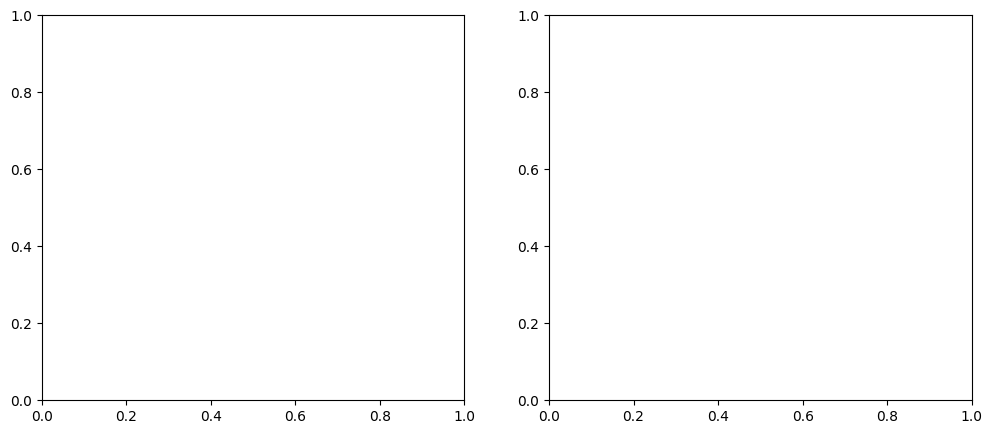

In [2]:



fig, axes = plt.subplots(1, 2, figsize=(12, 5))

categories = ["SW620 only", "Shared", "T84 only"]
up_counts   = [len(sw620_up - t84_up),   len(shared_up),   len(t84_up - sw620_up)]
down_counts = [len(sw620_down - t84_down), len(shared_down), len(t84_down - sw620_down)]

x = np.arange(3)
w = 0.35
axes[0].bar(x - w/2, up_counts,   w, label="Upregulated",   color="#d6604d", alpha=0.85)
axes[0].bar(x + w/2, down_counts, w, label="Downregulated", color="#2166ac", alpha=0.85)

for i, (u, d) in enumerate(zip(up_counts, down_counts)):
    axes[0].text(i - w/2, u + 1, str(u), ha="center", fontsize=9)
    axes[0].text(i + w/2, d + 1, str(d), ha="center", fontsize=9)

axes[0].set_xticks(x)
axes[0].set_xticklabels(categories, fontsize=9)
axes[0].set_ylabel("Number of DEGs")
axes[0].set_title("DEG overlap across cell lines")
axes[0].legend(frameon=False, fontsize=9)
axes[0].spines[["top", "right"]].set_visible(False)

top_shared_down = sorted(shared_down,
                         key=lambda g: res.loc[g, "log2FC"] if g in res.index else 0)[:15]
top_shared_up   = sorted(shared_up,
                         key=lambda g: res.loc[g, "log2FC"] if g in res.index else 0,
                         reverse=True)[:5]

plot_genes = top_shared_down + top_shared_up
fc_sw620 = [res.loc[g, "log2FC"]     if g in res.index     else 0 for g in plot_genes]
fc_t84   = [res_t84.loc[g, "log2FC"] if g in res_t84.index else 0 for g in plot_genes]

y = np.arange(len(plot_genes))
axes[1].barh(y + 0.2, fc_sw620, 0.35, color="#2166ac", alpha=0.85, label="SW620")
axes[1].barh(y - 0.2, fc_t84,   0.35, color="#d6604d", alpha=0.85, label="T84")
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_yticks(y)
axes[1].set_yticklabels(plot_genes, fontsize=8)
axes[1].set_xlabel("log₂ fold change")
axes[1].set_title("Top shared DEGs (log₂FC)")
axes[1].legend(frameon=False, fontsize=9)
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle("HCFC2 knockdown — consistent transcriptional effects across CRC cell lines",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig("summary_shared_DEGs.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved as summary_shared_DEGs.png")

